# Models

This file contains multiple models applied on the dataset
The code contains mistakes and generates comparisons between the wrong features (columns from the csv)
Your job is to use `data_analysis.ipynb` to find the correct relationships to achieve maximum accuracy 

**Imports:**

In [46]:
import os
import joblib
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.linear_model import ElasticNet

**Helper functions to use in later blocks:**

In [47]:
def evaluate_model(model_name):
    MODEL_DIR = "../models"
    model_path = os.path.join(MODEL_DIR, model_name + ".joblib")

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found: {model_path}")

    model = joblib.load(model_path)

    # Use global X_test and y_test
    global X_test, y_test

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"Evaluation metrics for {model_name}:")
    print(f"MSE: {mse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R^2: {r2:.4f}")

    METRICS_PATH = os.path.join(MODEL_DIR, "model_metrics.json")
    metrics = {}
    if os.path.exists(METRICS_PATH):
        with open(METRICS_PATH, "r") as f:
            metrics = json.load(f)

    metrics[model_name] = {"MSE": mse, "MAE": mae, "R2": r2}

    with open(METRICS_PATH, "w") as f:
        json.dump(metrics, f, indent=4)

    return y_pred

def plot_predictions(y_true, y_pred, model_name):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, alpha=0.6, edgecolors='k')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlabel("Actual " + target_column)
    plt.ylabel("Predicted " + target_column)
    plt.title(f"Predicted vs Actual Values ({model_name})")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Read Data

In [48]:
# read the csv file
df = pd.read_csv("../data/dataset.csv")

target_column = "power_consumption" # do not change this line
# this you are supposed to change to get better results
feature_columns = ["disk_io", "memory_usage", "cpu_utilization"] # TODO change to faulty ones

# Prepare data
X = df[feature_columns]
y = df[target_column]

# split data for train & test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# constants
model_name = ""
MODEL_DIR = "../models"

## Polynomial Regression

Evaluation metrics for polynomial_regression:
MSE: 5175.4829
MAE: 62.4093
R^2: 0.0009


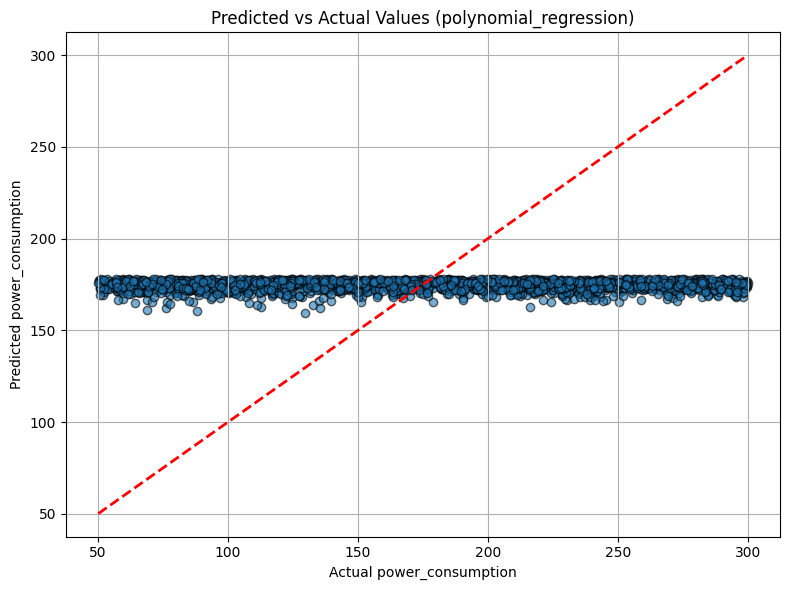

In [49]:
# name and path
model_name = "polynomial_regression"
MODEL_PATH = os.path.join(MODEL_DIR, model_name + ".joblib")

# Polynomial regression Parameters
degree = 2  # Polynomial degree

# Create and train pipeline model (handles polynomial features internally)
model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
model.fit(X_train, y_train)

# Save the trained pipeline model
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(model, MODEL_PATH)

# Evaluate and print metrics, then plot predictions
predictions = evaluate_model(model_name)
plot_predictions(y_test, predictions, model_name)

## Random Forest Regression

Evaluation metrics for random_forest_regression:
MSE: 5672.0734
MAE: 64.5254
R^2: -0.0950


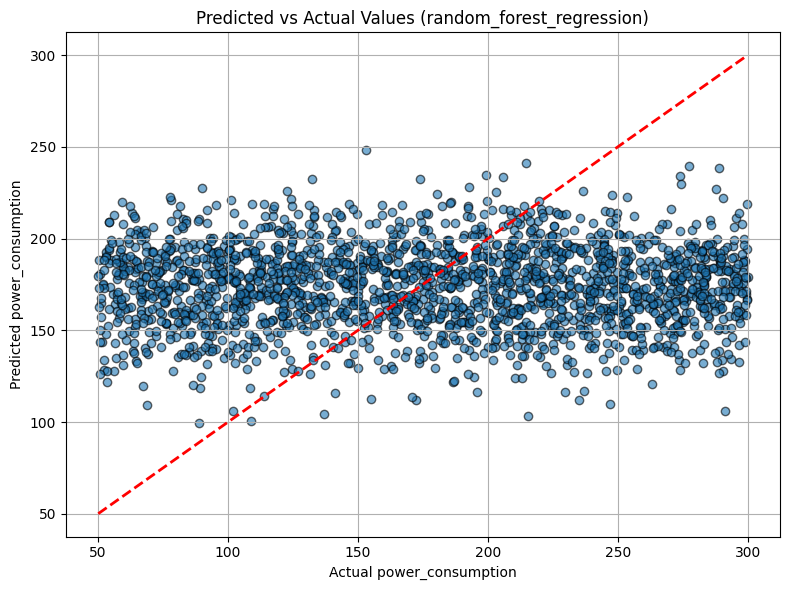

In [50]:
# Name and path
model_name = "random_forest_regression"
MODEL_PATH = os.path.join(MODEL_DIR, model_name + ".joblib")

# Hyperparameters for Random Forest (tweak these)
n_estimators = 100        # Number of trees in the forest
max_depth = None          # Maximum depth of each tree; None means nodes are expanded until all leaves are pure
min_samples_split = 2     # Minimum number of samples required to split an internal node
min_samples_leaf = 1      # Minimum number of samples required to be at a leaf node
random_state = 42         # Seed for reproducibility

# Create and train Random Forest Regressor with specified parameters
model = RandomForestRegressor(
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf,
    random_state=random_state
)
model.fit(X_train, y_train)

# Save the trained model
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(model, MODEL_PATH)

# Evaluate and print metrics, then plot predictions
predictions = evaluate_model(model_name)
plot_predictions(y_test, predictions, model_name)


## Multi-Layer Perceptron Regression

Evaluation metrics for mlp_regressor:
MSE: 5191.6022
MAE: 62.4994
R^2: -0.0022


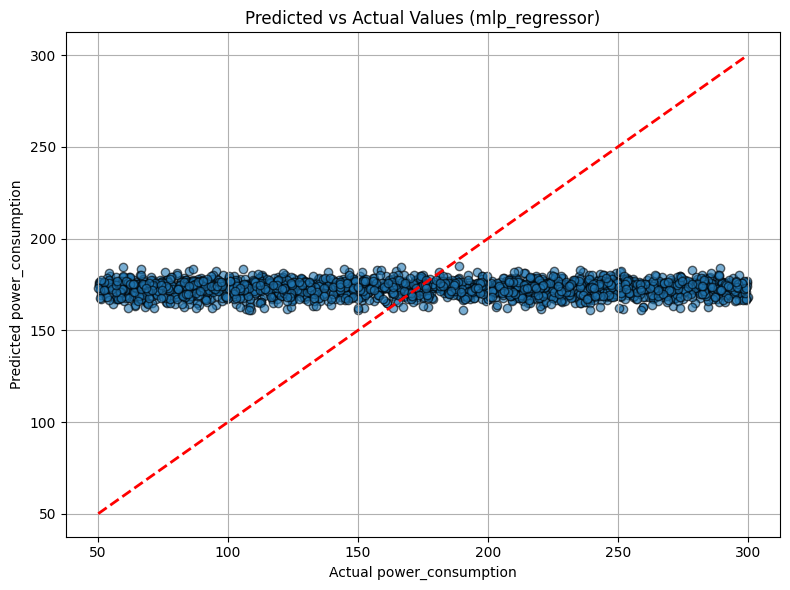

In [51]:
# name and path
model_name = "mlp_regressor"
MODEL_PATH = os.path.join(MODEL_DIR, model_name + ".joblib")

# MLP hyperparameters (tweak these for tuning)
hidden_layer_sizes = (100,)       # Tuple defining number of neurons per hidden layer; e.g., (100,) means one layer with 100 neurons
activation = 'relu'               # Activation function for hidden layers: 'relu', 'tanh', 'logistic' (sigmoid), etc.
solver = 'adam'                   # Optimizer: 'adam' (default), 'sgd', or 'lbfgs'
max_iter = 500                   # Maximum number of iterations during training (increase if model doesn't converge)
random_state = 42                # Seed for reproducibility

# Create and train MLP Regressor
model = MLPRegressor(hidden_layer_sizes=hidden_layer_sizes,
                     activation=activation,
                     solver=solver,
                     max_iter=max_iter,
                     random_state=random_state)

model.fit(X_train, y_train)

# Save the trained model
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(model, MODEL_PATH)

# Evaluate and print metrics, then plot predictions
predictions = evaluate_model(model_name)
plot_predictions(y_test, predictions, model_name)

## Support Vector Regression

Evaluation metrics for svr_regressor:
MSE: 5181.9854
MAE: 62.4457
R^2: -0.0004


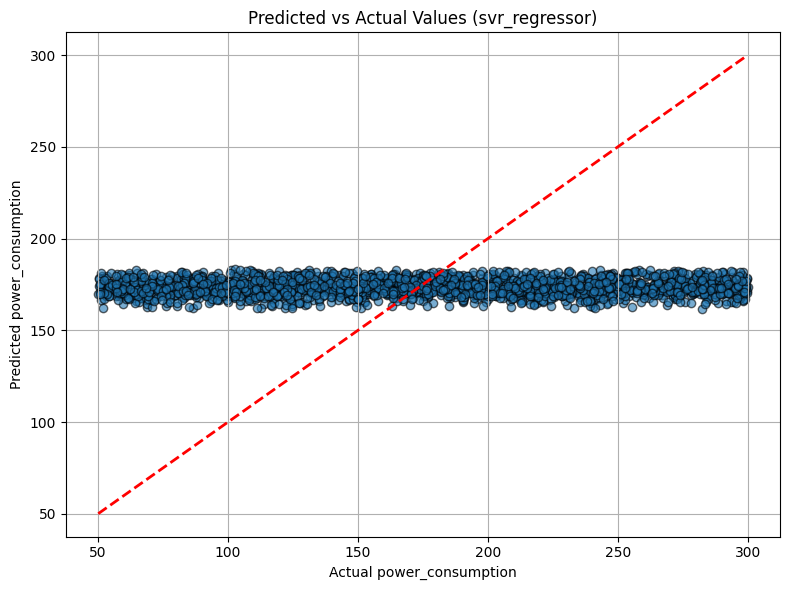

In [52]:
# name and path
model_name = "svr_regressor"
MODEL_PATH = os.path.join(MODEL_DIR, model_name + ".joblib")

# SVR hyperparameters (adjust to tune)
kernel = 'rbf'           # Kernel type: 'linear', 'poly', 'rbf', 'sigmoid'
C = 1.0                  # Regularization parameter; higher means less regularization
epsilon = 0.1            # Epsilon in the epsilon-insensitive loss function; controls margin of tolerance
gamma = 'scale'          # Kernel coefficient for 'rbf', 'poly', and 'sigmoid'; 'scale' or 'auto' or float value

# Create and train SVR model
model = SVR(kernel=kernel, C=C, epsilon=epsilon, gamma=gamma)
model.fit(X_train, y_train)

# Save the trained model
os.makedirs("../models", exist_ok=True)
joblib.dump(model, MODEL_PATH)

# Evaluate and plot
predictions = evaluate_model(model_name)
plot_predictions(y_test, predictions, model_name)


## Elastic Net

Evaluation metrics for elastic_net_regression:
MSE: 5183.6372
MAE: 62.4924
R^2: -0.0007


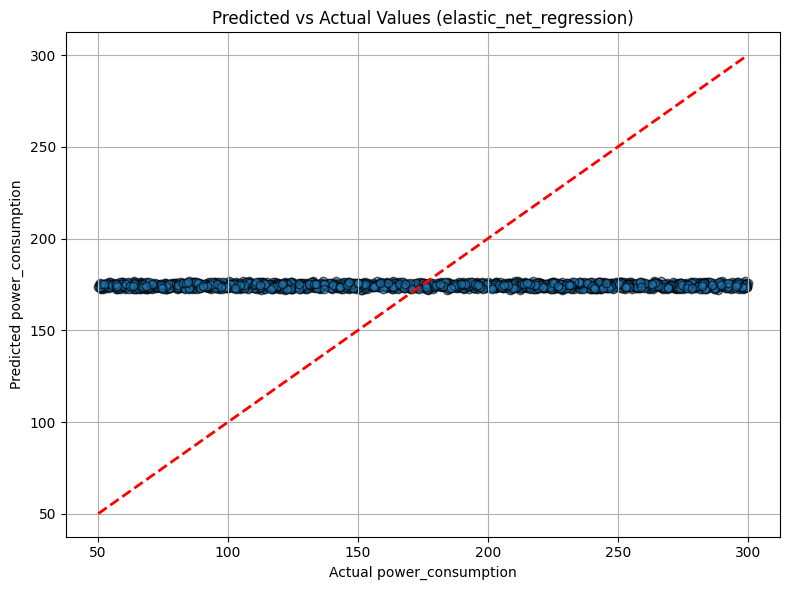

In [53]:
# name and path
model_name = "elastic_net_regression"
MODEL_PATH = os.path.join("../models", model_name + ".joblib")

# Elastic Net hyperparameters
alpha = 1.0         # Overall regularization strength; higher means more regularization
l1_ratio = 0.5      # Mix between L1 and L2 penalty (0 = Ridge, 1 = Lasso)
max_iter = 1000     # Max iterations for solver
random_state = 42   # For reproducibility

# Create and train Elastic Net model
model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=max_iter, random_state=random_state)
model.fit(X_train, y_train)

# Save the trained model
os.makedirs("../models", exist_ok=True)
joblib.dump(model, MODEL_PATH)

# Evaluate and plot
predictions = evaluate_model(model_name)
plot_predictions(y_test, predictions, model_name)
